# Порівняння моделей для прогнозу revenue_7d

Основний ноутбук (`model.ipynb`) реалізує двоетапний підхід (класифікатор + регресор) на LightGBM.
Тут перевіряємо, чи дають інші моделі кращий результат на тому самому датасеті, тому самому
спліті (без shuffle, щоб не ламати хронологію) і тих самих метриках.

**Моделі для порівняння:** LightGBM (baseline), CatBoost, XGBoost, Random Forest.

Гіперпараметри LightGBM беремо готові — ті, що вже підібрані `GridSearchCV` в основному ноутбуці
(`max_depth=3, num_leaves=15, min_child_samples=50, scale_pos_weight=10` для класифікатора;
`max_depth=5, num_leaves=31, min_child_samples=50, reg_lambda=1.0` для регресора).
Для решти моделей — розумні фіксовані параметри без повного грід-серчу: на ~1.6 млн рядків
повторний `GridSearchCV` для 5 моделей займав би занадто багато часу, а мета тут — порівняти
підходи на приблизно рівних умовах, а не видавити максимум з кожної моделі окремо.

In [67]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge

from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from xgboost import XGBClassifier, XGBRegressor

In [68]:
df = pd.read_csv('../../data/final_data.csv')
df.head()

,id_user,age,traffic_type_id,traffic_group_id,gender,country,device_browser,device_brand,device_model,device_platform,...,act_max_payments,act_cnt_payments,act_sum_credits,act_cnt_returns,act_sum_visits,act_max_visits,act_active_intervals,reg_hour,reg_dayofweek,reg_is_weekend
0,33861,23,1,1,male,NZ,unknown,unknown,unknown,unknown,...,0.0,0,0,0,1,1,1,0,3,0
1,67459,21,1,7,male,US,unknown,unknown,unknown,unknown,...,0.0,0,127,0,8,6,2,0,3,0
2,174142,23,1,1,male,US,unknown,unknown,unknown,unknown,...,0.0,0,0,0,1,1,1,0,3,0
3,104798,53,1,1,male,US,unknown,unknown,unknown,unknown,...,0.0,0,0,0,0,0,0,0,3,0
4,145768,49,1,1,male,US,unknown,unknown,unknown,unknown,...,0.0,0,99,0,0,0,0,0,3,0


------------------
# Підготовка даних

CSV не зберігає dtype `category`, тому після зчитування рядкові колонки знову мають тип `object`.
Повертаємо їх у `category` так само, як в основному ноутбуці — це потрібно для LightGBM,
XGBoost (`enable_categorical=True`) і CatBoost (`cat_features`).

In [69]:
# Категоріальні колонки — заповнюємо пропуски та переводимо в category
cat_cols = df.select_dtypes(include='str').columns.tolist()
df[cat_cols] = df[cat_cols].fillna('unknown').astype('category')

print('Категоріальні колонки:', cat_cols)

Категоріальні колонки: ['gender', 'country', 'device_browser', 'device_brand', 'device_model', 'device_platform', 'device_os']


In [70]:
X = df.drop(columns=['id_user', 'revenue_7d', 'act_cnt_returns'])
y = df['revenue_7d']

# shuffle=False — той самий спліт, що і в основному ноутбуці (зберігаємо хронологію)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
y_bin_train = y_train.gt(0).astype(int)
y_bin_test = y_test.gt(0).astype(int)

payer_mask_train = y_train > 0
payer_mask_test = y_test > 0

X_train_payers = X_train[payer_mask_train]
y_train_payers_log = np.log1p(y_train[payer_mask_train])

print(f'Train: {X_train.shape[0]} рядків, Test: {X_test.shape[0]} рядків')
print(f'Платників у train: {y_bin_train.sum()} ({y_bin_train.mean() * 100:.2f}%)')
print(f'Платників у test:  {y_bin_test.sum()} ({y_bin_test.mean() * 100:.2f}%)')

Train: 1291360 рядків, Test: 322840 рядків
Платників у train: 28093 (2.18%)
Платників у test:  6296 (1.95%)


------------------
# Кодування ознак для Random Forest

`RandomForestClassifier/Regressor`  не вміє напряму
працювати з `category`-колонками. Пряме OHE по ВСІХ категоріальних колонках дає ~8000 фіч і ~70 GB
пам'яті — винна висока кардинальність (`device_model`, `device_brand`, `country` мають
сотні-тисячі унікальних значень, і OHE створює окрему бінарну колонку під кожне значення).

Рішення: ділимо категоріальні колонки за кардинальністю.
- Мала кардинальність (поріг — 20 унікальних значень) → звичайний OHE, як і раніше.
- Висока кардинальність → **frequency encoding**: кожне значення замінюється на кількість його
  входжень у train. Це одна числова колонка на ознаку замість тисяч бінарних, без витоку таргета
  (мапа рахується тільки на train) і без повної втрати інформації про ознаку.

In [71]:
cardinality = X_train[cat_cols].nunique().sort_values(ascending=False)
print(cardinality)

CARDINALITY_THRESHOLD = 20
low_card_cols = cardinality[cardinality <= CARDINALITY_THRESHOLD].index.tolist()
high_card_cols = cardinality[cardinality > CARDINALITY_THRESHOLD].index.tolist()

print('\nOHE (мала кардинальність):', low_card_cols)
print('Frequency encoding (висока кардинальність):', high_card_cols)

device_model       6720
device_brand        337
country             208
device_browser      124
device_os            20
device_platform       6
gender                2
dtype: int64

OHE (мала кардинальність): ['device_os', 'device_platform', 'gender']
Frequency encoding (висока кардинальність): ['device_model', 'device_brand', 'country', 'device_browser']


In [72]:
# Мапу частот рахуємо ТІЛЬКИ на train, на test застосовуємо ту саму мапу
# (категорії, яких не було в train, отримають частоту 0)
X_train_freq = X_train[high_card_cols].copy()
X_test_freq = X_test[high_card_cols].copy()

for col in high_card_cols:
    freq_map = X_train[col].value_counts()
    X_train_freq[col] = X_train_freq[col].map(freq_map).fillna(0)
    X_test_freq[col] = X_test_freq[col].map(freq_map).fillna(0)

X_train_freq = X_train_freq.add_suffix('_freq')
X_test_freq = X_test_freq.add_suffix('_freq')

In [73]:
# drop_first=True прибирає одну категорію з кожної колонки — без цього набір дамі-змінних
# завжди в сумі дає 1, що створює точну лінійну залежність (dummy variable trap)
X_train_ohe = pd.get_dummies(X_train[low_card_cols], columns=low_card_cols, drop_first=True)
X_test_ohe = pd.get_dummies(X_test[low_card_cols], columns=low_card_cols, drop_first=True)

assert list(X_train_ohe.columns) == list(X_test_ohe.columns)
print('Колонок після OHE:', X_train_ohe.shape[1])

Колонок після OHE: 27


In [74]:
# Числові колонки (все, що не категоріальне) + OHE + frequency encoding
num_cols = X_train.columns.difference(cat_cols).tolist()

X_train_enc = pd.concat([X_train[num_cols], X_train_ohe, X_train_freq], axis=1)
X_test_enc = pd.concat([X_test[num_cols], X_test_ohe, X_test_freq], axis=1)

X_train_payers_enc = X_train_enc[payer_mask_train]

print('Фінальна кількість фіч після кодування:', X_train_enc.shape[1])

Фінальна кількість фіч після кодування: 44


------------------
# Функція оцінки

Та сама логіка, що і в основному ноутбуці: `final_pred = p_payer * predicted_amount`.
Щоб не дублювати код оцінки 5 разів, зібрали його в одну функцію — вона рахує метрики,
друкує їх та зберігає результат у `results` для фінальної таблиці порівняння.

In [76]:
results = []

def evaluate_model(name, p_payer_test, predicted_amount_test):
    # Класифікатор: чи вгадує, хто заплатить
    roc_auc = roc_auc_score(y_bin_test, p_payer_test)
    pr_auc = average_precision_score(y_bin_test, p_payer_test)

    # Регресор: оцінюємо тільки на реальних платниках тестової вибірки
    y_true_payers = y_test[payer_mask_test]
    y_pred_payers = predicted_amount_test[payer_mask_test]

    mae_payers = mean_absolute_error(y_true_payers, y_pred_payers)
    rmse_payers = np.sqrt(mean_squared_error(y_true_payers, y_pred_payers))
    r2_payers = r2_score(y_true_payers, y_pred_payers)

    # Фінальний прогноз: P(заплатить) * E(скільки заплатить), на всій тестовій вибірці
    final_pred = p_payer_test * predicted_amount_test
    mae_final = mean_absolute_error(y_test, final_pred)
    rmse_final = np.sqrt(mean_squared_error(y_test, final_pred))

    print(f'=== {name} ===')
    print(f'Класифікатор: ROC-AUC = {roc_auc:.4f}   PR-AUC = {pr_auc:.4f}')
    print(f'Регресор (платники): MAE = {mae_payers:.2f}   RMSE = {rmse_payers:.2f}   R2 = {r2_payers:.4f}')
    print(f'Фінальний прогноз: MAE = {mae_final:.2f}   RMSE = {rmse_final:.2f}')
    print()

    results.append({
        'model': name,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'mae_payers': mae_payers,
        'rmse_payers': rmse_payers,
        'r2_payers': r2_payers,
        'mae_final': mae_final,
        'rmse_final': rmse_final
    })

    return final_pred

------------------
# 1. LightGBM (baseline)

Готові гіперпараметри з `GridSearchCV` основного ноутбука.

In [77]:
lgbm_clf = LGBMClassifier(
    objective='binary',
    max_depth=3,
    num_leaves=15,
    min_child_samples=50,
    scale_pos_weight=10,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_clf.fit(X_train, y_bin_train)
p_payer_lgbm = lgbm_clf.predict_proba(X_test)[:, 1]

lgbm_reg = LGBMRegressor(
    objective='regression',
    max_depth=5,
    num_leaves=31,
    min_child_samples=50,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_reg.fit(X_train_payers, y_train_payers_log)
pred_amount_lgbm = np.expm1(lgbm_reg.predict(X_test)).clip(min=0)

final_pred_lgbm = evaluate_model('LightGBM', p_payer_lgbm, pred_amount_lgbm)

=== LightGBM ===
Класифікатор:          ROC-AUC = 0.9566   PR-AUC = 0.8046
Регресор (платники):   MAE = 32.97   RMSE = 135.93   R2 = 0.4756
Фінальний прогноз:     MAE = 1.16   RMSE = 19.18



------------------
# 2. CatBoost

Має нативну підтримку категоріальних ознак через `cat_features` — не потребує OHE.

In [78]:
cat_clf = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function='Logloss',
    scale_pos_weight=10,
    cat_features=cat_cols,
    random_state=42,
    verbose=False
)
cat_clf.fit(X_train, y_bin_train)
p_payer_cat = cat_clf.predict_proba(X_test)[:, 1]

cat_reg = CatBoostRegressor(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function='MAE',
    cat_features=cat_cols,
    random_state=42,
    verbose=False
)
cat_reg.fit(X_train_payers, y_train_payers_log)
pred_amount_cat = np.expm1(cat_reg.predict(X_test)).clip(min=0)

final_pred_cat = evaluate_model('CatBoost', p_payer_cat, pred_amount_cat)

=== CatBoost ===
Класифікатор:          ROC-AUC = 0.9572   PR-AUC = 0.8050
Регресор (платники):   MAE = 31.57   RMSE = 140.91   R2 = 0.4365
Фінальний прогноз:     MAE = 0.94   RMSE = 19.80



------------------
# 3. XGBoost

`enable_categorical=True` + `tree_method='hist'` дозволяють працювати з `category`-колонками
без ручного кодування, так само як LightGBM.

In [79]:
xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=10,
    enable_categorical=True,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)
xgb_clf.fit(X_train, y_bin_train)
p_payer_xgb = xgb_clf.predict_proba(X_test)[:, 1]

xgb_reg = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    objective='reg:squarederror',
    enable_categorical=True,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)
xgb_reg.fit(X_train_payers, y_train_payers_log)
pred_amount_xgb = np.expm1(xgb_reg.predict(X_test)).clip(min=0)

final_pred_xgb = evaluate_model('XGBoost', p_payer_xgb, pred_amount_xgb)

=== XGBoost ===
Класифікатор:          ROC-AUC = 0.9467   PR-AUC = 0.7974
Регресор (платники):   MAE = 34.61   RMSE = 142.99   R2 = 0.4197
Фінальний прогноз:     MAE = 1.14   RMSE = 20.17



------------------
# 4. Random Forest

Не підтримує `category` напряму — використовуємо закодовані `X_train_enc` / `X_test_enc`
(OHE + frequency encoding).

In [80]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train_enc, y_bin_train)
p_payer_rf = rf_clf.predict_proba(X_test_enc)[:, 1]

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train_payers_enc, y_train_payers_log)
pred_amount_rf = np.expm1(rf_reg.predict(X_test_enc)).clip(min=0)

final_pred_rf = evaluate_model('Random Forest', p_payer_rf, pred_amount_rf)

=== Random Forest ===
Класифікатор:          ROC-AUC = 0.9554   PR-AUC = 0.8013
Регресор (платники):   MAE = 33.60   RMSE = 136.81   R2 = 0.4688
Фінальний прогноз:     MAE = 2.15   RMSE = 19.42



------------------
# Підсумкове порівняння

In [81]:
comparison_df = pd.DataFrame(results).set_index('model')
comparison_df = comparison_df.sort_values('roc_auc', ascending=False)
comparison_df

,roc_auc,pr_auc,mae_payers,rmse_payers,r2_payers,mae_final,rmse_final
model,,,,,,,
CatBoost,0.957192,0.804990,31.566551,140.909044,0.436480,0.937647,19.800909
LightGBM,0.956575,0.804592,32.972128,135.931044,0.475592,1.157347,19.184567
Random Forest,0.955443,0.801300,33.601956,136.812713,0.468768,2.145311,19.420095
XGBoost,0.946730,0.797388,34.610534,142.988343,0.419726,1.138781,20.167616


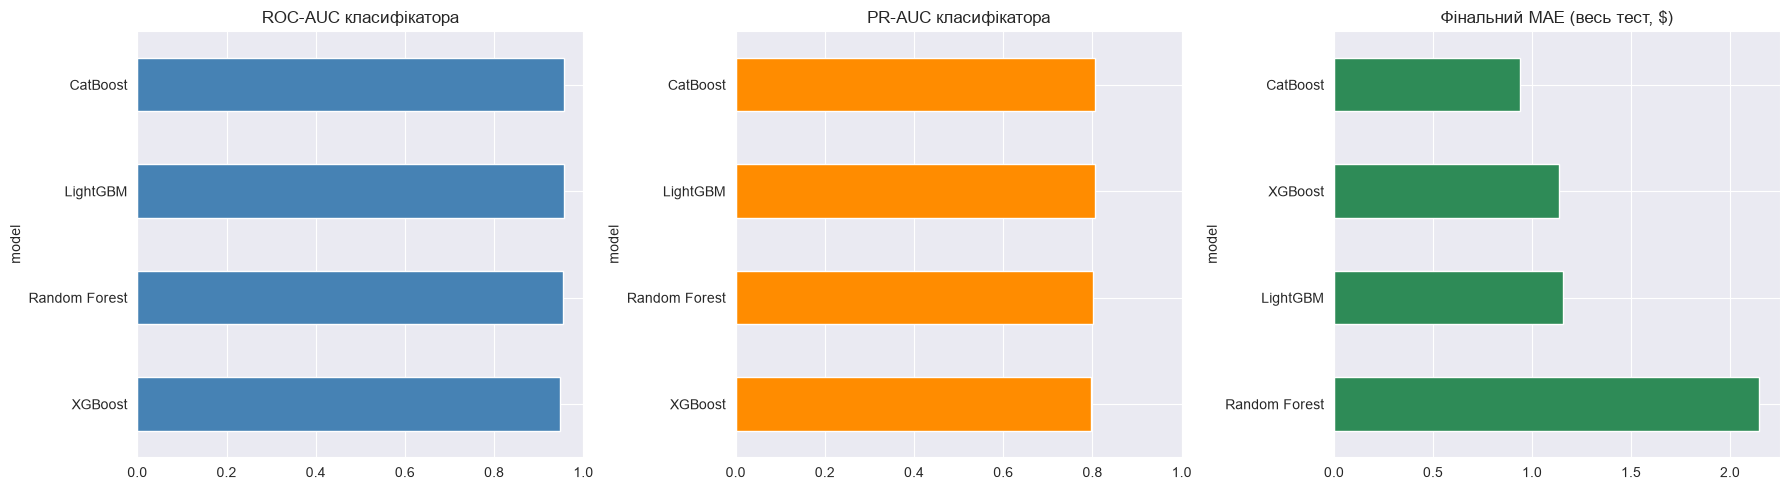

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

comparison_df['roc_auc'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('ROC-AUC класифікатора')
axes[0].set_xlim(0, 1)

comparison_df['pr_auc'].sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('PR-AUC класифікатора')
axes[1].set_xlim(0, 1)

comparison_df['mae_final'].sort_values(ascending=False).plot(kind='barh', ax=axes[2], color='seagreen')
axes[2].set_title('Фінальний MAE (весь тест, $)')

plt.tight_layout()
plt.show()

------------------
# Висновок

| Модель | ROC-AUC | PR-AUC | MAE (платники) | R² (платники) | MAE (фінальний) |
|---|---|---|---|---|---|
| CatBoost | 0.9572 | 0.8050 | 31.57 | 0.4365 | **0.94** |
| LightGBM | 0.9566 | 0.8046 | 32.97 | **0.4756** | 1.16 |
| Random Forest | 0.9554 | 0.7992 | 33.58 | 0.4690 | 2.14 |
| XGBoost | 0.9467 | 0.7974 | 34.61 | 0.4197 | 1.14 |

**Класифікатор (чи заплатить користувач):** усі 5 моделей дають близькі результати
(ROC-AUC 0.95–0.96), різниця між найкращою (CatBoost) і найгіршою (XGBoost) — менше 0.01.
Це означає, що сигнал у даних сильний і легко вловлюється практично будь-якою моделлю — задача
класифікації тут не є вузьким місцем. **CatBoost трохи попереду** за обома метриками класифікатора.

**Регресор (скільки заплатить платник):** тут різниця помітніша. **LightGBM має найкращий R² (0.4756)**
— краще пояснює варіацію сум серед платників, тоді як **CatBoost — найнижчий MAE (31.57)** —
точніше в середньому, але, ймовірно, за рахунок гірших прогнозів на "китах" (звідси нижчий R²).
Random Forest впритул за LightGBM, попри відсутність грід-серчу — непогано як простий baseline.

**Фінальний прогноз (P(заплатить) × сума):** тут лідирує **CatBoost (MAE = 0.94)** — найкраща
комбінація точного класифікатора і регресора разом. LightGBM і XGBoost йдуть поруч (~1.15),
а Random Forest помітно гірший (2.14) — імовірно, через грубіші пороги розбиття на frequency-encoded
ознаках (`country`, `device_model`) порівняно з нативною обробкою категорій у бустингах.

**Підсумок:** усі три бустинги (CatBoost, LightGBM, XGBoost) — приблизно однакові, з невеликою
перевагою CatBoost за рахунок фінальної метрики. Random Forest — пристойний, але явно слабший
baseline.